In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


In [2]:
#Read USGS north arm gage
gage_readings = r"USGS//Daily_Combined.csv"
df = pd.read_csv(gage_readings)

#remove columns we dont care about
df = df.drop(columns=["x","y","id","time_series_id",'monitoring_location_id', 'parameter_code',
       'statistic_id','last_modified','approval_status', 'qualifier'])
df.columns = ["date",'elev','unit'] #renaming columns

#add 3.475 to convert to the correct datum, convert to meters
df['elevft'] = (df['elev'] + 3.47585958)
df['elev'] = df['elevft']  * 0.3048


#CLEAN THE DATA
#sort
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df = df.sort_values("date").reset_index(drop=True)
df = df.drop_duplicates().reset_index(drop=True)
print(df.head())

df.to_csv(r"USGS//cleaned.csv")
start_date = "2013-12-15"
end_date   = "2016-12-01"
df = df[
    (df["date"] >= start_date) &
    (df["date"] <= end_date)
].reset_index(drop=True)


        date         elev unit      elevft
0 2013-01-01  1279.933186   ft  4199.25586
1 2013-01-02  1279.930138   ft  4199.24586
2 2013-01-03  1279.933186   ft  4199.25586
3 2013-01-04  1279.930138   ft  4199.24586
4 2013-01-05  1279.933186   ft  4199.25586


In [3]:


#Read stage-area-volume data
sav = r"USGS//Great_Salt_Lake_2023_ElevAreaVolume_north_arm.csv"
sav = pd.read_csv(sav)

#rename columns so it works with my previous calculations
sav = sav.rename(columns={'elev_ft_NAVD88':'stage_m'})
sav['stage_m'] = sav['stage_m'] * 0.3048


In [4]:

#ensure numeric for join
df['elev'] = pd.to_numeric(df['elev'], errors="coerce")
sav['stage_m'] = pd.to_numeric(sav['stage_m'], errors="coerce")


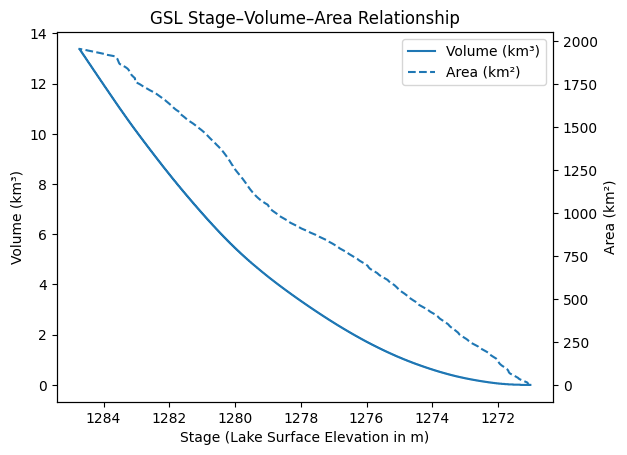

In [20]:
fig, ax1 = plt.subplots()

# Volume on left axis
line1, = ax1.plot(
    sv["stage_m"],
    sv["volume_km3"],
    label="Volume (km³)"
)
ax1.set_xlabel("Stage (Lake Surface Elevation in m)")
ax1.set_ylabel("Volume (km³)")

# Area on right axis
ax2 = ax1.twinx()
line2, = ax2.plot(
    sv["stage_m"],
    sv["area_km2"],
    linestyle="--",
    label="Area (km²)"
)
ax2.set_ylabel("Area (km²)")

ax1.invert_xaxis()

# combined legend
ax1.legend(
    handles=[line1, line2],
    loc="best"
)

plt.title("GSL Stage–Volume–Area Relationship")
plt.show()


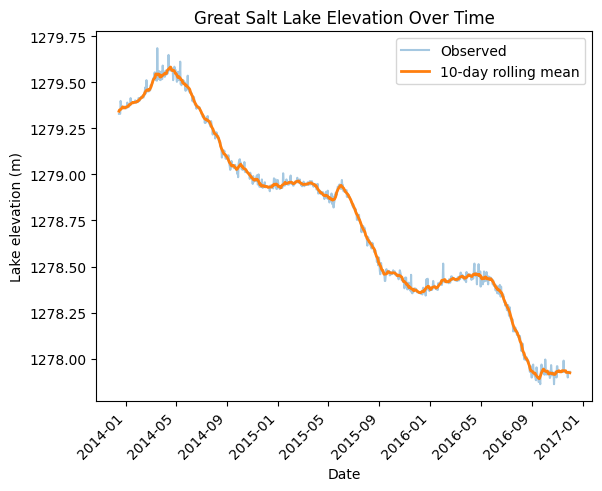

In [ ]:

# make sure elevations are numeric
df["elev"] = pd.to_numeric(df["elev"], errors="coerce")

# interpolate volume and area at each observed lake elevation
df["volume_km3"] = np.interp(
    df["elev"].to_numpy(),
    stage_volume["stage_m"].to_numpy(),
    stage_volume["volume_km3"].to_numpy()
)

df["area_km2"] = np.interp(
    df["elev"].to_numpy(),
    stage_volume["stage_m"].to_numpy(),
    stage_volume["area_km2"].to_numpy()
)


#resort by date
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")

#Calculate the monthly change in lake volume
df['dv'] = df['volume_km3'] - df['volume_km3'].shift(1)

# make sure date is datetime + sorted
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")

# rolling window (months)
window = 10   #days

df["elev_smooth"] = df["elev"].rolling(
    window=window,
    center=True,
    min_periods=1
).mean()

plt.figure()
plt.plot(df["date"], df["elev"], alpha=0.4, label="Observed")
plt.plot(df["date"], df["elev_smooth"], linewidth=2, label=f"{window}-day rolling mean")

plt.xticks(rotation=45, ha="right")
plt.xlabel("Date")
plt.ylabel("Stage (m)")
plt.title("Great Salt Lake Elevation Over Time")
plt.legend()

plt.show()


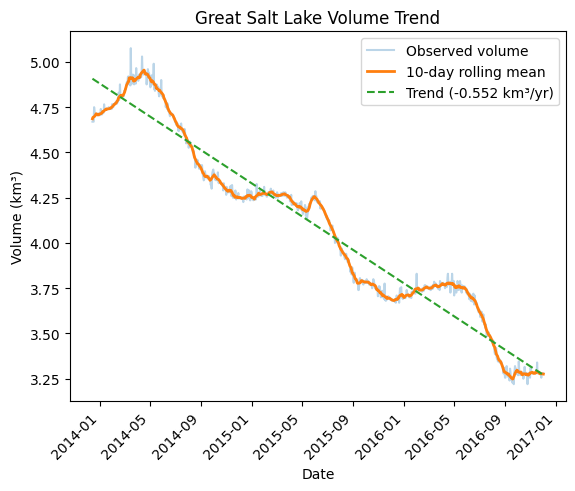

Trend rate (smoothed): -0.5519 km³ per year


In [12]:

# make sure date is datetime + sorted
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df = df.sort_values("date").reset_index(drop=True)

# smooth volume (rolling mean)
window = 10  # day
df["volume_smooth"] = df["volume_km3"].rolling(
    window=window,
    center=True,
    min_periods=1
).mean()

# fit trend to smoothed volume
mask = df["date"].notna() & df["volume_smooth"].notna()

x_fit = mdates.date2num(df.loc[mask, "date"])
y_fit = df.loc[mask, "volume_smooth"].to_numpy()

m, b = np.polyfit(x_fit, y_fit, 1)

# evaluate trend for all dates
x_all = mdates.date2num(df["date"])
trend = m * x_all + b

# slope in km³/year (m is km³/day)
slope_year = m * 365

# plot
plt.figure()
plt.plot(df["date"], df["volume_km3"], alpha=0.3, label="Observed volume")
plt.plot(df["date"], df["volume_smooth"], linewidth=2, label=f"{window}-day rolling mean")
plt.plot(df["date"], trend, linestyle="--", label=f"Trend ({slope_year:.3f} km³/yr)")

plt.xticks(rotation=45, ha="right")
plt.xlabel("Date")
plt.ylabel("Volume (km³)")
plt.title("Great Salt Lake Volume Trend")
plt.legend()

plt.show()

print(f"Trend rate (smoothed): {slope_year:.4f} km³ per year")

In [8]:
#Given our rate of volume decline, calculate (linearly) how long it would take for the GSL to go to 0
#years = (Vcurrent - Vtarget) / rate
targetft = 4170
targetft = targetft + 3.47585958 #datum conversion
target = targetft * 0.3048

currentft = 4192
currentft = currentft + 3.47585958 #datum conversion
current = currentft * 0.3048


stage_volume = sav[['stage_m','volume_km3']].sort_values('stage_m')


volume_at_current = np.interp(current, stage_volume["stage_m"], stage_volume["volume_km3"])
volume_at_target = np.interp(target ,stage_volume['stage_m'],stage_volume['volume_km3'])

print(f"Current volume at current({current}): {volume_at_current}\nVolume at target({target}): {volume_at_target}")
print(f"Difference: {volume_at_current-volume_at_target}km3\nRate: {slope_year}km3 per year")



rate = abs(slope_year)
years = (volume_at_current - volume_at_target) / rate


print(f"Rate: {rate}")
print(f"Years: {years}")

Current volume at current(1278.7810419999842): 4.09585958000077
Volume at target(1272.0754419999842): 0.07
Difference: 4.02585958000077km3
Rate: -0.5520260327420594km3 per year
Rate: 0.5520260327420594
Years: 7.292879939018926
